In [63]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [6]:
df = pd.read_csv('../Data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [7]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [8]:
df.shape

(7043, 21)

In [9]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [11]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [12]:
df.duplicated().sum()


np.int64(0)

In [13]:
# check the value count of the churn value 

df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [14]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

# EDA

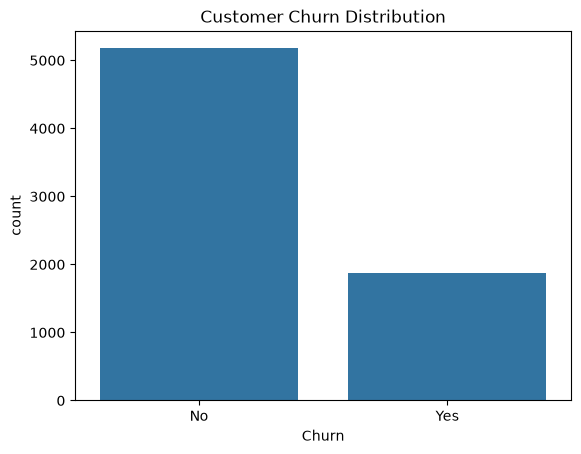

In [15]:
sns.countplot(x="Churn", data=df)

plt.title("Customer Churn Distribution")
plt.show()


In [16]:
# Does Gander affect churn
df["gender"].value_counts(normalize=True) * 100

gender
Male      50.47565
Female    49.52435
Name: proportion, dtype: float64

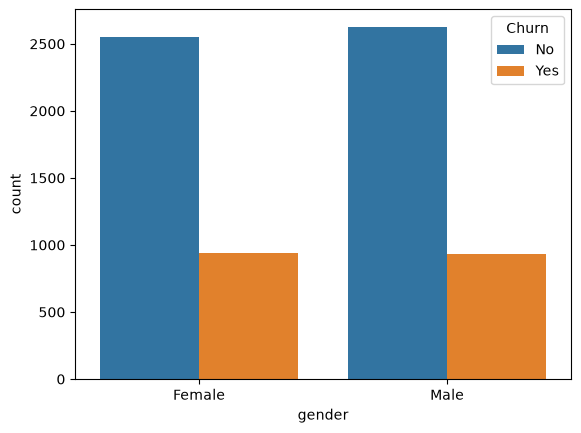

In [17]:
# Does Gander affect churn

sns.countplot(x="gender", hue="Churn", data=df)

plt.show()

In [18]:
# Does Contract affect churn

df["Contract"].value_counts(normalize=True) * 100

Contract
Month-to-month    55.019168
Two year          24.066449
One year          20.914383
Name: proportion, dtype: float64

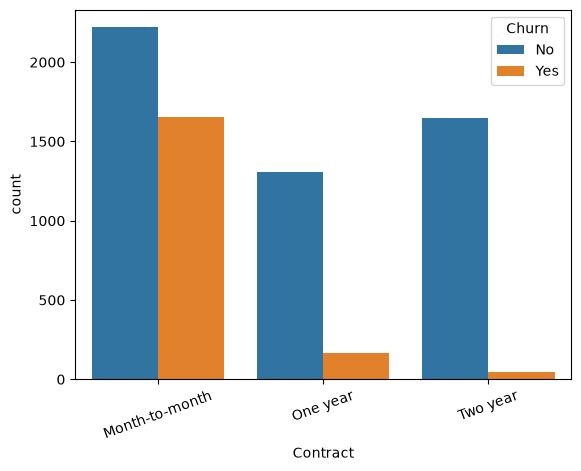

In [19]:
sns.countplot(x="Contract", hue="Churn", data=df)

plt.xticks(rotation=20)

plt.show()

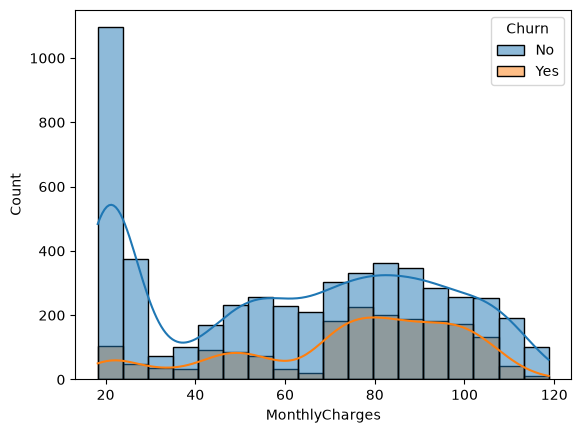

In [20]:
# relation with high monthly chareges

sns.histplot(data=df,
             x="MonthlyCharges",
             hue="Churn",
             kde=True)

plt.show()

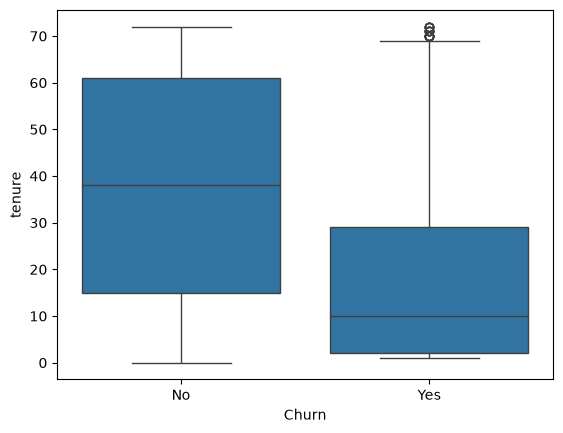

In [21]:
# relation with tenure

sns.boxplot(x="Churn",
            y="tenure",
            data=df)

plt.show()

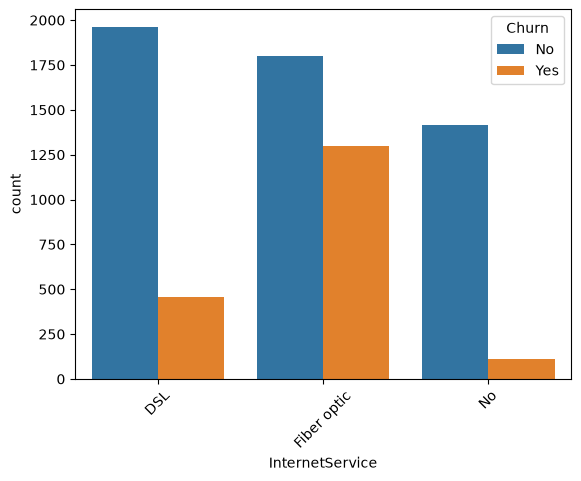

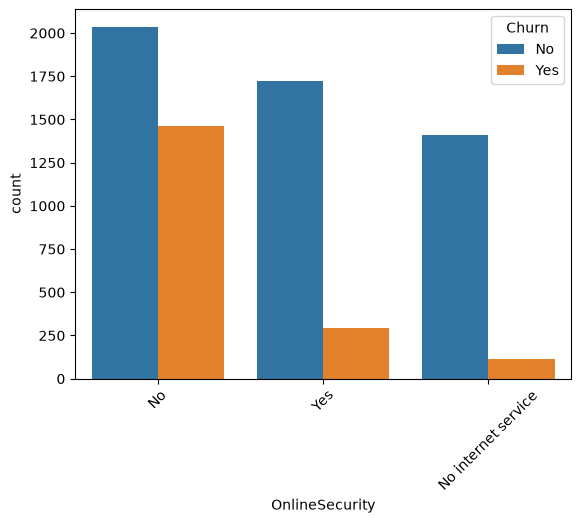

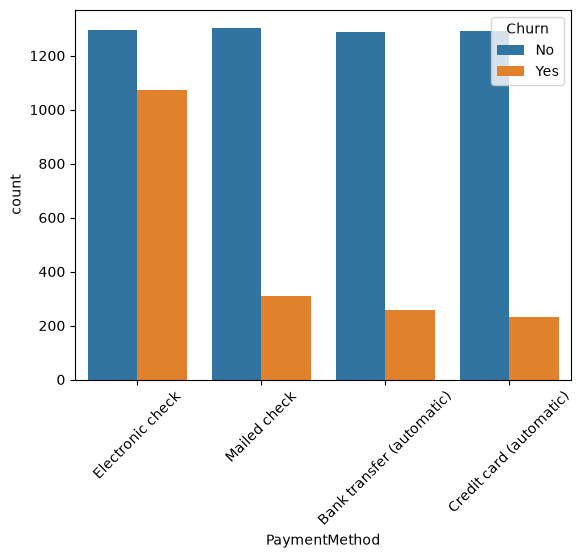

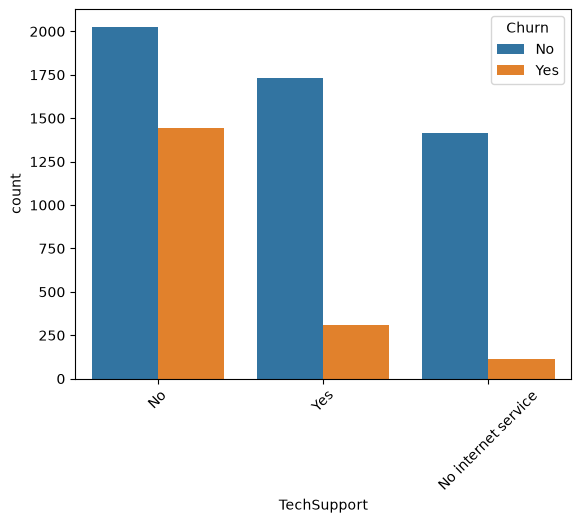

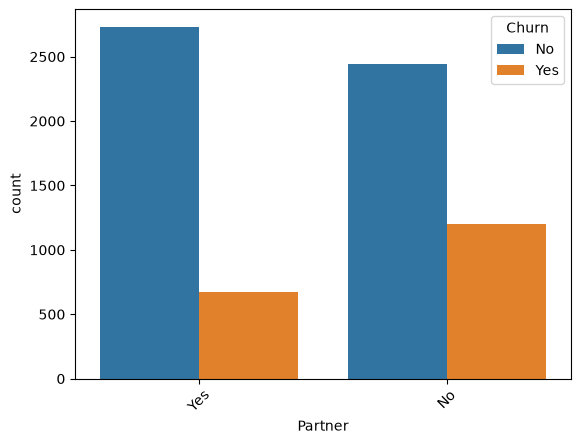

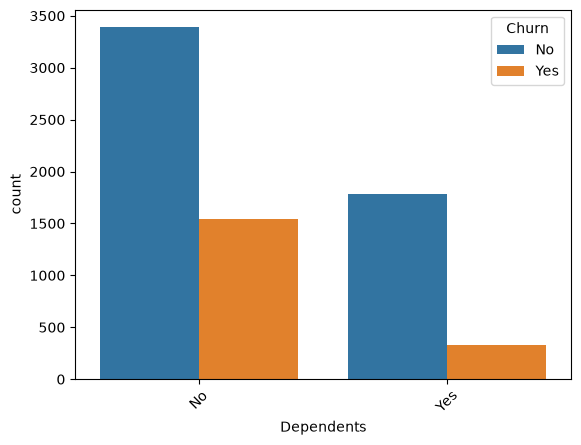

In [23]:
important_cols = [
    "InternetService",
    "OnlineSecurity",
    "PaymentMethod",
    "TechSupport",
    "Partner",
    "Dependents"
]

for col in important_cols:
    sns.countplot(x=col, hue="Churn", data=df)
    plt.xticks(rotation=45)
    plt.show()

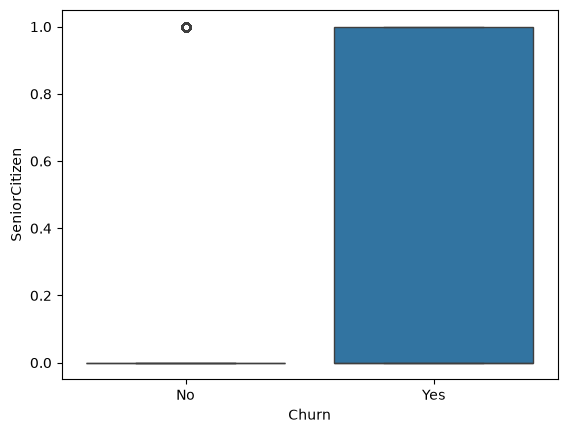

In [28]:
sns.boxplot(x="Churn",
            y="SeniorCitizen",
            data=df)

plt.show()

Feature Selection

In [33]:
selected = [
    "Partner",
    "Dependents",
    "Contract",
    "tenure",          # lowercase
    "MonthlyCharges",
    "OnlineSecurity",
    "TechSupport",
    "InternetService",
    "PaymentMethod",
    "Churn"
]

df_final = df[selected]

In [34]:
df_final.head()

,Partner,Dependents,Contract,tenure,MonthlyCharges,OnlineSecurity,TechSupport,InternetService,PaymentMethod,Churn
0,Yes,No,Month-to-month,1,29.85,No,No,DSL,Electronic check,No
1,No,No,One year,34,56.95,Yes,No,DSL,Mailed check,No
2,No,No,Month-to-month,2,53.85,Yes,No,DSL,Mailed check,Yes
3,No,No,One year,45,42.30,Yes,Yes,DSL,Bank transfer (automatic),No
4,No,No,Month-to-month,2,70.70,No,No,Fiber optic,Electronic check,Yes


In [38]:
x = df_final.drop("Churn" , axis=1)
y = df_final["Churn"]


Encoding

In [39]:
y = y.map({"Yes": 1, "No": 0})

In [40]:
x = pd.get_dummies(x, drop_first=True)

In [59]:
x.columns

Index(['tenure', 'MonthlyCharges', 'IsPartner', 'HasDependents',
       'Contract_OneYear', 'Contract_TwoYear', 'NoInternet_OnlineSecurity',
       'HasOnlineSecurity', 'NoInternet_TechSupport', 'HasTechSupport',
       'FiberOptic', 'NoInternet', 'Payment_CreditCard',
       'Payment_ElectronicCheck', 'Payment_MailedCheck'],
      dtype='str')

In [44]:
x.rename(columns={
    "Partner_Yes": "IsPartner",
    "Dependents_Yes": "HasDependents",

    "Contract_One year": "Contract_OneYear",
    "Contract_Two year": "Contract_TwoYear",

    "OnlineSecurity_No internet service": "NoInternet_OnlineSecurity",
    "OnlineSecurity_Yes": "HasOnlineSecurity",

    "TechSupport_No internet service": "NoInternet_TechSupport",
    "TechSupport_Yes": "HasTechSupport",

    "InternetService_Fiber optic": "FiberOptic",
    "InternetService_No": "NoInternet",

    "PaymentMethod_Credit card (automatic)": "Payment_CreditCard",
    "PaymentMethod_Electronic check": "Payment_ElectronicCheck",
    "PaymentMethod_Mailed check": "Payment_MailedCheck"
}, inplace=True)

In [58]:
# convert string to int 

bool_cols = x.select_dtypes(include="bool").columns
x[bool_cols] = x[bool_cols].astype(int)


Train test split 

In [60]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42
)


Feature Scaling | doing after split because -----> 

* Before splitting, the scaler learns the mean and standard deviation of the entire dataset, including the test set. This is called data leakage, and it's considered bad practice.

In [61]:
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)   # Fit only on training data
x_test = scaler.transform(x_test)         # Transform test data using same scaler

Models Building 

- Logistic Regression

In [64]:
lr = LogisticRegression(random_state=42)


lr.fit(x_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

In [65]:
y_pred = lr.predict(x_test)

In [69]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


Accuracy : 0.808374733853797
Precision: 0.6666666666666666
Recall   : 0.5522788203753352
F1 Score : 0.6041055718475073
ROC AUC  : 0.7264289854772429
[[933 103]
 [167 206]]


In [67]:
print("Train Accuracy:", lr.score(x_train, y_train))
print("Test Accuracy :", lr.score(x_test, y_test))

Train Accuracy: 0.7932197373091942
Test Accuracy : 0.808374733853797


- Decission Tree 

In [71]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(x_train, y_train)


,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [72]:
y_pred = dt.predict(x_test)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


Accuracy : 0.7317246273953159
Precision: 0.4931506849315068
Recall   : 0.48257372654155495
F1 Score : 0.4878048780487805
ROC AUC  : 0.6520011489850631
[[851 185]
 [193 180]]


In [73]:
print("Train Accuracy:", dt.score(x_train, y_train))
print("Test Accuracy :", dt.score(x_test, y_test))

Train Accuracy: 0.9724884629037983
Test Accuracy : 0.7317246273953159
